# Housing EDA

In [2]:
##Importing packages
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
%matplotlib inline

# Importing Dataset

In [6]:
Housing = pd.read_csv("housing.csv")
Housing

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.000000,0.165514,0.067815,0.0,0.273696,0.455845,0.495675,0.238389,0.000000,0.188979,0.252496,0.693147,0.085884,3.218876
1,0.000236,0.000000,0.242302,0.0,0.159428,0.436962,0.578128,0.299335,0.042560,0.099811,0.440312,0.693147,0.186040,3.117950
2,0.000236,0.000000,0.242302,0.0,0.159428,0.527320,0.469617,0.299335,0.042560,0.099811,0.440312,0.688003,0.061533,3.575151
3,0.000293,0.000000,0.063050,0.0,0.139941,0.505947,0.365901,0.370559,0.083382,0.064658,0.500130,0.690281,0.032843,3.538057
4,0.000705,0.000000,0.063050,0.0,0.139941,0.523014,0.424170,0.370559,0.083382,0.064658,0.500130,0.693147,0.094708,3.616309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.000633,0.000000,0.420455,0.0,0.327021,0.458029,0.519848,0.115711,0.000000,0.151967,0.638489,0.686938,0.198109,3.152736
502,0.000438,0.000000,0.420455,0.0,0.327021,0.398993,0.565337,0.100111,0.000000,0.151967,0.638489,0.693147,0.184664,3.072693
503,0.000612,0.000000,0.420455,0.0,0.327021,0.503402,0.645695,0.090189,0.000000,0.151967,0.638489,0.693147,0.102459,3.214868
504,0.001160,0.000000,0.420455,0.0,0.327021,0.482097,0.636473,0.108419,0.000000,0.151967,0.638489,0.688788,0.123165,3.135494


# Understanding Dataset

In [7]:
## Understanding the data types
Housing.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [8]:
##Check for missing Value and count them
Housing.isna().value_counts()

CRIM   ZN     INDUS  CHAS   NOX    RM     AGE    DIS    RAD    TAX    PTRATIO  B      LSTAT  MEDV 
False  False  False  False  False  False  False  False  False  False  False    False  False  False    506
Name: count, dtype: int64

In [9]:
## Conducting simple Stat on our Data
Housing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,0.036362,0.090296,0.391378,0.047945,0.284651,0.416052,0.500107,0.206017,0.282694,0.328215,0.473075,0.631214,0.252679,3.085437
std,0.077805,0.175973,0.251479,0.176055,0.170604,0.088357,0.186799,0.146027,0.249808,0.215915,0.153716,0.151792,0.144934,0.386966
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.791759
25%,0.000851,0.000000,0.173387,0.000000,0.123710,0.368380,0.360350,0.084579,0.122602,0.161755,0.412532,0.665637,0.134565,2.891757
50%,0.002808,0.000000,0.338343,0.000000,0.273696,0.410307,0.570007,0.173069,0.160343,0.241298,0.522455,0.686240,0.235648,3.100092
75%,0.040430,0.117783,0.646628,0.000000,0.399963,0.461718,0.662162,0.314141,0.693147,0.649259,0.592504,0.692296,0.350738,3.258097
max,0.693147,0.693147,1.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,3.931826


# Checking for Relationship and Correlation 

<Axes: title={'center': 'Distribution of MEDV'}, ylabel='Frequency'>

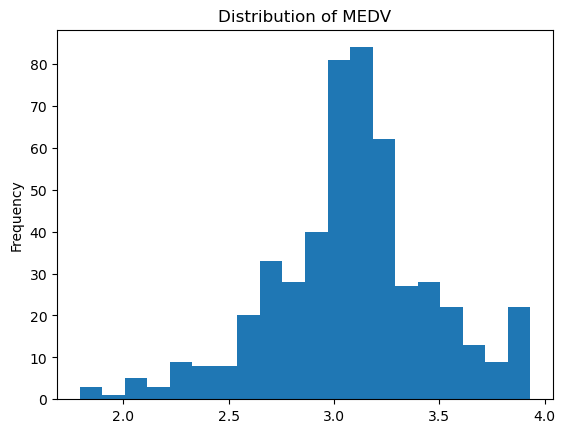

In [10]:
Housing["MEDV"].plot(kind="hist", 
                     bins=20, 
                     title="Distribution of MEDV")

In [11]:
print(Housing.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')


In [12]:
##Finding Pattern (Comparison of Crime Rate and House Value)
Housing["Crime_Level"] = pd.qcut(Housing["CRIM"], 
                                 q=3, 
                                 labels=["Low Crime", "Medium Crime", "High Crime"]);

Housing["MEDV_Category"] = pd.qcut(Housing["MEDV"], 
                                   q=3, 
                                   labels=["Low Value", "Medium Value", "High Value"]);

In [13]:
pd.crosstab(Housing["Crime_Level"], 
            Housing["MEDV_Category"])

MEDV_Category,Low Value,Medium Value,High Value
Crime_Level,,,
Low Crime,11,72,86
Medium Crime,48,61,59
High Crime,110,38,21


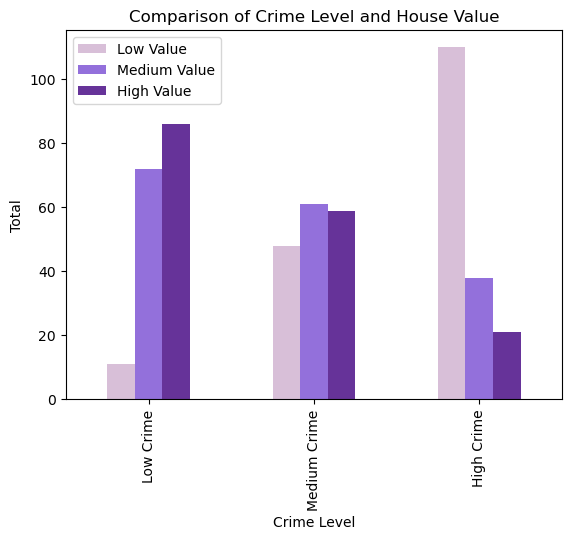

In [14]:
pd.crosstab(Housing["Crime_Level"], 
            Housing["MEDV_Category"]).plot(kind="bar", 
                                           color=["thistle", "mediumpurple", "rebeccapurple"]);

plt.title("Comparison of Crime Level and House Value")
plt.xlabel("Crime Level")
plt.ylabel("Total")
plt.legend(["Low Value", "Medium Value", "High Value"])
plt.show()

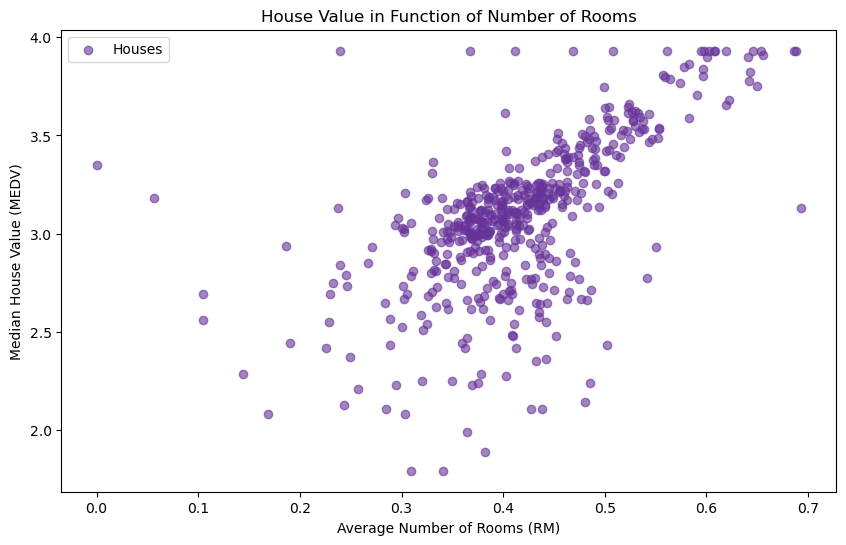

In [15]:
##Checking Correlation between Number of Rooms and House Value
plt.figure(figsize=(10, 6))
plt.scatter(Housing["RM"], Housing ["MEDV"], 
            color="rebeccapurple", 
            alpha=0.6, 
            label="Houses");

plt.title("House Value in Function of Number of Rooms")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.legend()
plt.show()

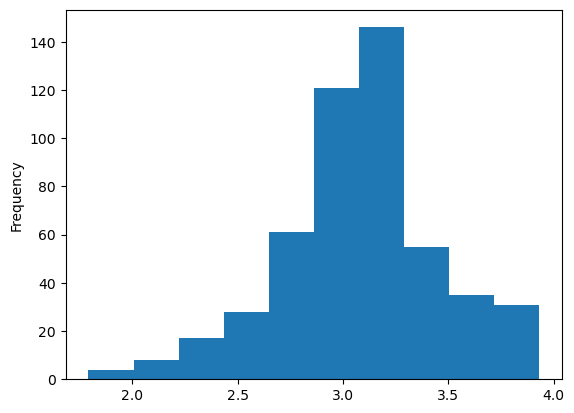

In [16]:
##Distribution of House Values
Housing.MEDV.plot.hist();

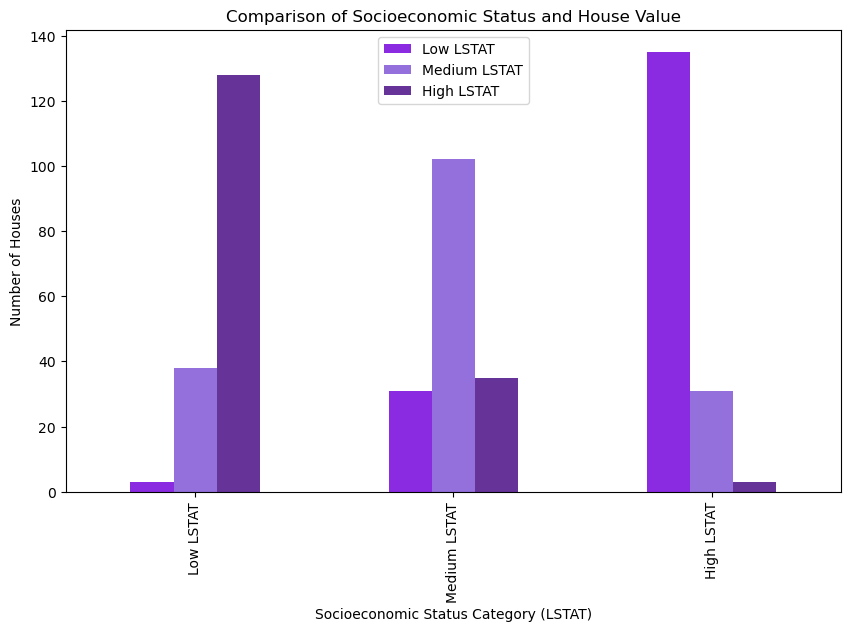

In [17]:
##Relationship between Lower Status Population (LSTAT) and House Value
Housing["LSTAT_Level"] = pd.qcut(Housing["LSTAT"], 
                                 q=3, 
                                 labels=["Low LSTAT", "Medium LSTAT", "High LSTAT"]); 

pd.crosstab(Housing["LSTAT_Level"], 
            Housing["MEDV_Category"]).plot(kind="bar",
                                           figsize=(10,6), 
                                           color=["blueviolet", "mediumpurple", "rebeccapurple"]);

plt.title("Comparison of Socioeconomic Status and House Value")
plt.xlabel("Socioeconomic Status Category (LSTAT)")
plt.ylabel("Number of Houses")
plt.legend(["Low LSTAT", "Medium LSTAT", "High LSTAT"])
plt.show()

In [22]:
##Correlation
hd_corr = Housing.select_dtypes(include='number').corr()
hd_corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.234224,0.450599,-0.056781,0.476531,-0.254630,0.371290,-0.443309,0.682456,0.626683,0.303758,-0.417889,0.488157,-0.552605
ZN,-0.234224,1.000000,-0.552637,-0.042626,-0.575243,0.319252,-0.582854,0.663127,-0.329272,-0.329403,-0.404825,0.177850,-0.447602,0.376076
INDUS,0.450599,-0.552637,1.000000,0.062938,0.778622,-0.394649,0.622307,-0.729265,0.590862,0.717042,0.362812,-0.342996,0.615297,-0.541258
CHAS,-0.056781,-0.042626,0.062938,1.000000,0.083917,0.085432,0.089106,-0.095668,-0.003409,-0.036637,-0.115121,0.050903,-0.056003,0.159435
NOX,0.476531,-0.575243,0.778622,0.083917,1.000000,-0.315791,0.745019,-0.825852,0.625502,0.676497,0.190497,-0.365573,0.609830,-0.513568
RM,-0.254630,0.319252,-0.394649,0.085432,-0.315791,1.000000,-0.242799,0.235376,-0.216814,-0.303379,-0.343648,0.118296,-0.628776,0.621283
AGE,0.371290,-0.582854,0.622307,0.089106,0.745019,-0.242799,1.000000,-0.753761,0.443612,0.483720,0.228336,-0.254685,0.601019,-0.438227
DIS,-0.443309,0.663127,-0.729265,-0.095668,-0.825852,0.235376,-0.753761,1.000000,-0.517500,-0.556501,-0.212319,0.295019,-0.523315,0.359984
RAD,0.682456,-0.329272,0.590862,-0.003409,0.625502,-0.216814,0.443612,-0.517500,1.000000,0.886076,0.442176,-0.437525,0.487880,-0.472155
TAX,0.626683,-0.329403,0.717042,-0.036637,0.676497,-0.303379,0.483720,-0.556501,0.886076,1.000000,0.424395,-0.427695,0.545290,-0.558498


In [23]:
import seaborn as sns

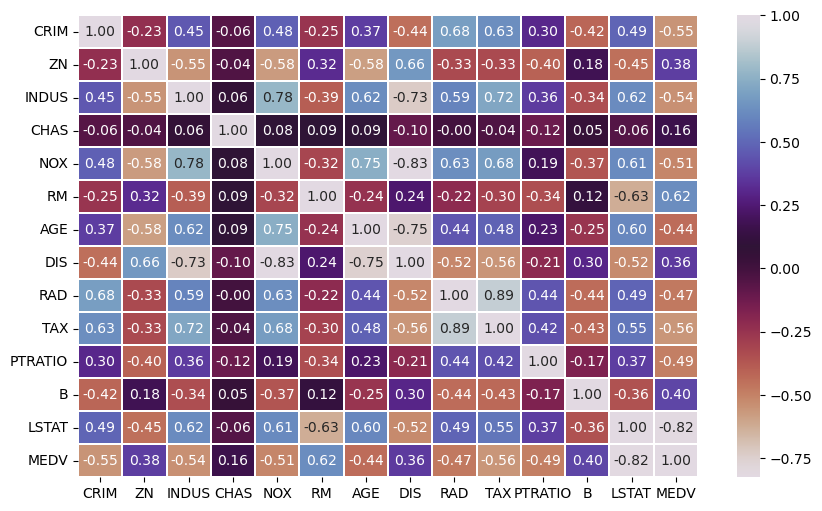

In [25]:
ax,fig = plt.subplots(figsize=(10,6))
ax= sns.heatmap(hd_corr, annot=True, 
                linewidths = 0.2, 
                fmt="0.2f", 
                cmap="twilight_r");